# 17 - ML Experiments: One Variable at a Time

Structured ML evaluation for the 137-study dataset. Each experiment changes one thing, measures the effect, and carries the winner forward to the next experiment.

**Fixed methodology across all experiments:**
- Evaluation: LOOCV (137 folds)
- Scaling: StandardScaler fit inside each fold
- Metric: AUC from collected LOO probabilities + Youden threshold
- Random state: 42 everywhere

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from boruta import BorutaPy
import warnings
warnings.filterwarnings("ignore")

In [13]:
df = pd.read_csv(os.path.join("reports", "13_merged_radiomics_clinical.csv"))
feature_cols = [c for c in df.columns if c.startswith("original_")]
y_full = df["rejection"].values

# Remove correlated features (|r| > 0.9), keep the one with lower p-value
stats_df = pd.read_csv(os.path.join("reports", "14a_stats_radiomics_features.csv"))
p_values = dict(zip(stats_df["feature"], stats_df["p_value"]))

corr = df[feature_cols].corr().abs()
to_drop = set()
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        if corr.iloc[i, j] > 0.9:
            fi, fj = feature_cols[i], feature_cols[j]
            if fi in to_drop or fj in to_drop:
                continue
            if p_values.get(fi, 1.0) <= p_values.get(fj, 1.0):
                to_drop.add(fj)
            else:
                to_drop.add(fi)

reduced_features = [f for f in feature_cols if f not in to_drop]
X_full = df[reduced_features].values

print(f"Samples: {len(df)} ({sum(y_full == 0)} no-rej, {sum(y_full == 1)} rej)")
print(f"Features: {len(feature_cols)} -> {len(reduced_features)} after correlation removal")

Samples: 137 (98 no-rej, 39 rej)
Features: 93 -> 32 after correlation removal


In [14]:
def run_loocv(X, y, make_model):
    loo = LeaveOneOut()
    y_proba = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X):
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X[train_idx])
        X_te = scaler.transform(X[test_idx])
        model = make_model()
        model.fit(X_tr, y[train_idx])
        y_proba[test_idx] = model.predict_proba(X_te)[:, 1]
    return y_proba

def compute_youden(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    J = tpr - fpr
    best = np.argmax(J)
    return {
        "auc": auc, "threshold": thresholds[best],
        "sensitivity": tpr[best], "specificity": 1 - fpr[best],
        "fpr": fpr, "tpr": tpr,
    }

## Experiment 1: Which algorithm works best?

**Change:** algorithm
**Hold constant:** all features, default hyperparameters, LOOCV

In [15]:
model_defs = {
    "LogReg": lambda: LogisticRegression(
        C=1.0, penalty="l2", class_weight="balanced", max_iter=1000, random_state=42),
    "RF": lambda: RandomForestClassifier(
        n_estimators=100, max_depth=5, min_samples_leaf=5,
        class_weight="balanced", random_state=42),
    "SVM": lambda: SVC(
        kernel="rbf", probability=True, class_weight="balanced", random_state=42),
    "NaiveBayes": lambda: GaussianNB(),
}

exp1_results = {}
for name, make_model in model_defs.items():
    y_proba = run_loocv(X_full, y_full, make_model)
    result = compute_youden(y_full, y_proba)
    result["y_proba"] = y_proba
    exp1_results[name] = result
    print(f"{name:12s}  AUC = {result['auc']:.3f}  "
          f"sens = {result['sensitivity']:.3f}  spec = {result['specificity']:.3f}")

# Carry forward: pick the algorithm with highest AUC
best_model_name = max(exp1_results, key=lambda k: exp1_results[k]["auc"])
best_model_fn = model_defs[best_model_name]
best_X = X_full
best_feature_names = list(reduced_features)
print(f"\n-> Carrying forward: {best_model_name} (AUC = {exp1_results[best_model_name]['auc']:.3f})")

LogReg        AUC = 0.462  sens = 0.923  spec = 0.153
RF            AUC = 0.431  sens = 0.154  spec = 0.929
SVM           AUC = 0.427  sens = 0.795  spec = 0.224
NaiveBayes    AUC = 0.497  sens = 0.974  spec = 0.122

-> Carrying forward: NaiveBayes (AUC = 0.497)


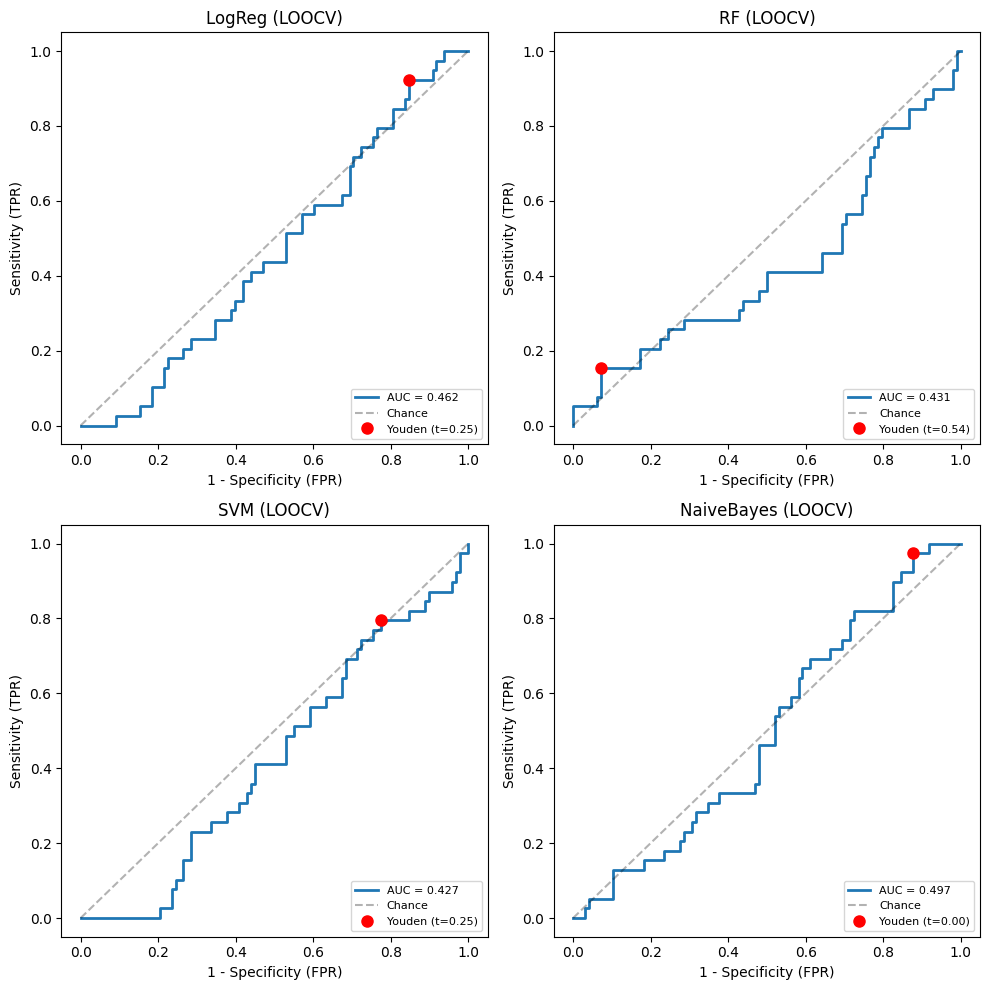

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for idx, (name, res) in enumerate(exp1_results.items()):
    ax = axes.flatten()[idx]
    ax.plot(res["fpr"], res["tpr"], linewidth=2, label=f"AUC = {res['auc']:.3f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Chance")

    # Mark Youden point
    J = res["tpr"] - res["fpr"]
    best = np.argmax(J)
    ax.plot(res["fpr"][best], res["tpr"][best], "ro", markersize=8,
            label=f"Youden (t={res['threshold']:.2f})")

    ax.set_xlabel("1 - Specificity (FPR)")
    ax.set_ylabel("Sensitivity (TPR)")
    ax.set_title(f"{name} (LOOCV)")
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join("reports", "17_exp1_roc_algorithms.png"), dpi=150, bbox_inches="tight")
plt.show()

## Experiment 2: Does feature selection help?

**Change:** feature set
**Hold constant:** best algorithm from Exp 1, LOOCV

Two approaches (Gemma asked for at least 2):
1. **Boruta** - tests each feature against shuffled shadow copies
2. **Iterative elimination** - rank features by importance, evaluate LOOCV at each subset size

In [17]:
rf_boruta = RandomForestClassifier(
    n_estimators=100, max_depth=5, min_samples_leaf=5,
    class_weight="balanced", random_state=42)

scaler_b = StandardScaler()
X_scaled = scaler_b.fit_transform(best_X)

boruta = BorutaPy(rf_boruta, n_estimators="auto", max_iter=200, random_state=42, verbose=0)
boruta.fit(X_scaled, y_full)

confirmed = [f for f, s in zip(best_feature_names, boruta.support_) if s]
tentative = [f for f, s in zip(best_feature_names, boruta.support_weak_) if s]

print(f"Boruta confirmed: {len(confirmed)} features")
print(f"Boruta tentative: {len(tentative)} features")
print(f"Boruta rejected:  {sum(~boruta.support_ & ~boruta.support_weak_)} features")
if confirmed:
    print(f"Confirmed: {confirmed}")
if tentative:
    print(f"Tentative: {tentative}")
if len(confirmed) == 0 and len(tentative) == 0:
    print("\nBoruta found no features better than random noise.")

Boruta confirmed: 0 features
Boruta tentative: 0 features
Boruta rejected:  32 features

Boruta found no features better than random noise.


Running feature elimination curve...


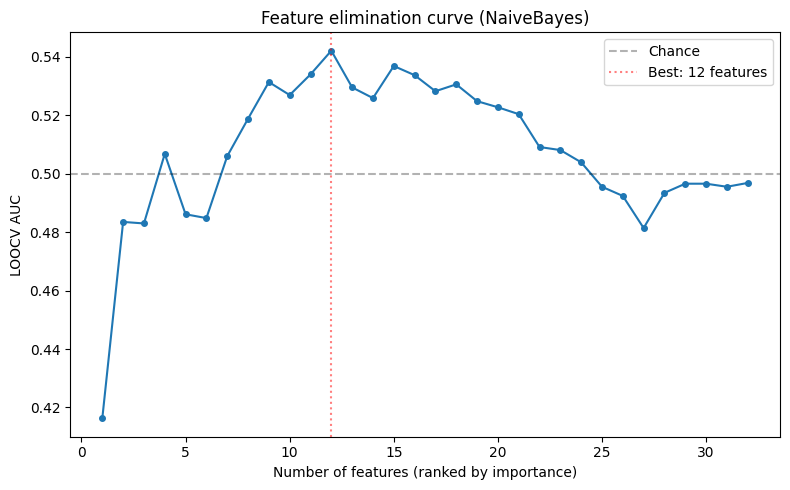


All 32 features:  AUC = 0.497
Best RFE subset (12 features): AUC = 0.542

-> Carrying forward: top 12 RFE features (AUC = 0.542)


In [18]:
# Rank features using permutation importance on the full dataset
scaler_r = StandardScaler()
X_sc = scaler_r.fit_transform(best_X)
rank_model = best_model_fn()
rank_model.fit(X_sc, y_full)
perm = permutation_importance(rank_model, X_sc, y_full, n_repeats=10,
                               scoring="roc_auc", random_state=42)
feature_order = np.argsort(perm.importances_mean)[::-1]

# Evaluate LOOCV at each subset size
print("Running feature elimination curve...")
rfe_aucs = []
for n in range(1, len(best_feature_names) + 1):
    X_subset = best_X[:, feature_order[:n]]
    y_proba = run_loocv(X_subset, y_full, best_model_fn)
    rfe_aucs.append(roc_auc_score(y_full, y_proba))

best_n = np.argmax(rfe_aucs) + 1
best_rfe_auc = rfe_aucs[best_n - 1]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(rfe_aucs) + 1), rfe_aucs, "o-", markersize=4)
plt.axhline(0.5, color="k", linestyle="--", alpha=0.3, label="Chance")
plt.axvline(best_n, color="r", linestyle=":", alpha=0.5, label=f"Best: {best_n} features")
plt.xlabel("Number of features (ranked by importance)")
plt.ylabel("LOOCV AUC")
plt.title(f"Feature elimination curve ({best_model_name})")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join("reports", "17_exp2_rfe_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

# Carry forward: compare all features vs Boruta vs best RFE subset
baseline_auc = exp1_results[best_model_name]["auc"]
boruta_features = confirmed + tentative
print(f"\nAll {len(best_feature_names)} features:  AUC = {baseline_auc:.3f}")
print(f"Best RFE subset ({best_n} features): AUC = {best_rfe_auc:.3f}")

if len(boruta_features) > 0:
    boruta_idx = [best_feature_names.index(f) for f in boruta_features]
    y_proba_b = run_loocv(best_X[:, boruta_idx], y_full, best_model_fn)
    boruta_auc = roc_auc_score(y_full, y_proba_b)
    print(f"Boruta features ({len(boruta_features)}):    AUC = {boruta_auc:.3f}")

# Pick the best feature set
if best_rfe_auc > baseline_auc + 0.02:
    best_X = best_X[:, feature_order[:best_n]]
    best_feature_names = [best_feature_names[i] for i in feature_order[:best_n]]
    print(f"\n-> Carrying forward: top {best_n} RFE features (AUC = {best_rfe_auc:.3f})")
else:
    print(f"\n-> Carrying forward: all {len(best_feature_names)} features (no meaningful improvement from selection)")

## Experiment 3: Do better hyperparameters help?

**Change:** hyperparameters
**Hold constant:** best algorithm + features from Exp 1-2

Uses 5-fold stratified CV for grid search (LOOCV with grid search produces NaN scores). Then confirms the best params with LOOCV.

In [19]:
all_param_grids = {
    "LogReg": {
        "base": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
        "grid": {"C": [0.01, 0.1, 1.0, 10.0]},
    },
    "RF": {
        "base": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
        "grid": {"max_depth": [3, 5, 7], "min_samples_leaf": [3, 5, 10]},
    },
    "SVM": {
        "base": SVC(probability=True, class_weight="balanced", random_state=42),
        "grid": {"C": [0.1, 1.0, 10.0], "kernel": ["linear", "rbf"]},
    },
    "NaiveBayes": {
        "base": GaussianNB(),
        "grid": {"var_smoothing": [1e-9, 1e-7, 1e-5]},
    },
}

spec = all_param_grids[best_model_name]
cv_grid = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scaler_g = StandardScaler()
X_gs = scaler_g.fit_transform(best_X)

gs = GridSearchCV(spec["base"], spec["grid"], cv=cv_grid, scoring="roc_auc", n_jobs=-1)
gs.fit(X_gs, y_full)

print(f"Grid search ({best_model_name}):")
print(f"  Best 5-fold CV AUC: {gs.best_score_:.3f}")
print(f"  Best params: {gs.best_params_}")

# Confirm with LOOCV
tuned_estimator = gs.best_estimator_
best_model_fn = lambda e=tuned_estimator: clone(e)
y_proba_tuned = run_loocv(best_X, y_full, best_model_fn)
tuned_auc = roc_auc_score(y_full, y_proba_tuned)

print(f"  LOOCV AUC with best params: {tuned_auc:.3f}")
print(f"  LOOCV AUC before tuning:    {exp1_results[best_model_name]['auc']:.3f}")
print(f"\n-> Carrying forward: {best_model_name} with params {gs.best_params_}")

Grid search (NaiveBayes):
  Best 5-fold CV AUC: 0.593
  Best params: {'var_smoothing': 1e-09}
  LOOCV AUC with best params: 0.542
  LOOCV AUC before tuning:    0.497

-> Carrying forward: NaiveBayes with params {'var_smoothing': 1e-09}


## Experiment 4: Final evaluation

**Change:** nothing - this is the final result
**Using:** best algorithm + features + hyperparameters from Experiments 1-3

Run LOOCV one final time. Plot the ROC curve. Report AUC, sensitivity, specificity at Youden threshold.

Final pipeline results (full dataset, LOOCV):
  AUC:         0.542
  Threshold:   0.584 (Youden)
  Sensitivity: 0.692
  Specificity: 0.480


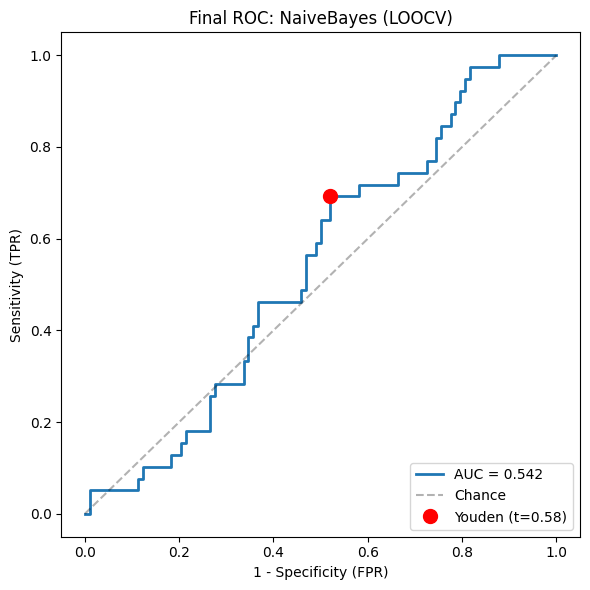

In [20]:
y_proba_final = run_loocv(best_X, y_full, best_model_fn)
final = compute_youden(y_full, y_proba_final)

print("Final pipeline results (full dataset, LOOCV):")
print(f"  AUC:         {final['auc']:.3f}")
print(f"  Threshold:   {final['threshold']:.3f} (Youden)")
print(f"  Sensitivity: {final['sensitivity']:.3f}")
print(f"  Specificity: {final['specificity']:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(final["fpr"], final["tpr"], linewidth=2, label=f"AUC = {final['auc']:.3f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Chance")
J = final["tpr"] - final["fpr"]
best = np.argmax(J)
ax.plot(final["fpr"][best], final["tpr"][best], "ro", markersize=10,
        label=f"Youden (t={final['threshold']:.2f})")
ax.set_xlabel("1 - Specificity (FPR)")
ax.set_ylabel("Sensitivity (TPR)")
ax.set_title(f"Final ROC: {best_model_name} (LOOCV)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join("reports", "17_exp4_roc_final.png"), dpi=150, bbox_inches="tight")
plt.show()

## Experiment 5: Does the late subset change anything?

**Change:** dataset (full -> late subset, motivo 3/4/5)
**Hold constant:** final pipeline from Experiment 4

The late subset (70 samples) has better class balance and restricts to later post-transplant studies where rejection effects may be more pronounced.

Late subset: 70 samples (41 no-rej, 29 rej)

Late subset results (LOOCV):
  AUC:         0.574
  Threshold:   0.002 (Youden)
  Sensitivity: 0.966
  Specificity: 0.195


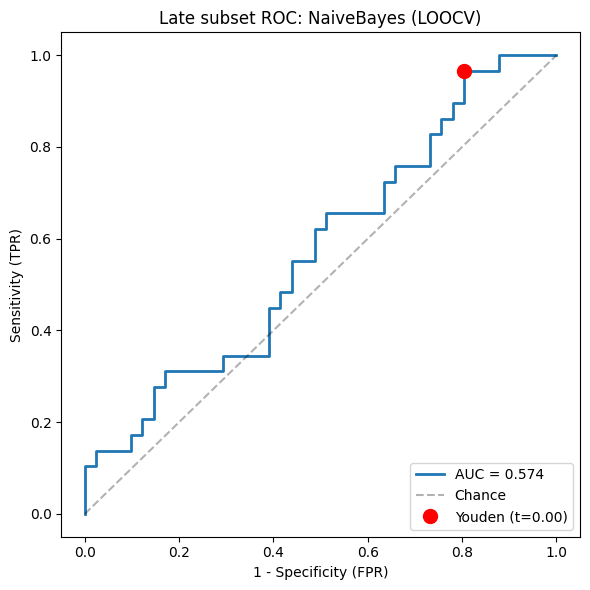

In [21]:
late_mask = df["motivo"].isin([3, 4, 5])
X_late = df.loc[late_mask, best_feature_names].values
y_late = df.loc[late_mask, "rejection"].values

print(f"Late subset: {len(X_late)} samples ({sum(y_late == 0)} no-rej, {sum(y_late == 1)} rej)")

y_proba_late = run_loocv(X_late, y_late, best_model_fn)
late = compute_youden(y_late, y_proba_late)

print(f"\nLate subset results (LOOCV):")
print(f"  AUC:         {late['auc']:.3f}")
print(f"  Threshold:   {late['threshold']:.3f} (Youden)")
print(f"  Sensitivity: {late['sensitivity']:.3f}")
print(f"  Specificity: {late['specificity']:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(late["fpr"], late["tpr"], linewidth=2, label=f"AUC = {late['auc']:.3f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Chance")
J = late["tpr"] - late["fpr"]
best_j = np.argmax(J)
ax.plot(late["fpr"][best_j], late["tpr"][best_j], "ro", markersize=10,
        label=f"Youden (t={late['threshold']:.2f})")
ax.set_xlabel("1 - Specificity (FPR)")
ax.set_ylabel("Sensitivity (TPR)")
ax.set_title(f"Late subset ROC: {best_model_name} (LOOCV)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join("reports", "17_exp5_roc_late.png"), dpi=150, bbox_inches="tight")
plt.show()

In [22]:
summary = pd.DataFrame([
    {"experiment": "Exp 1: Algorithm", "detail": best_model_name,
     "AUC": round(exp1_results[best_model_name]["auc"], 3)},
    {"experiment": "Exp 2: Features", "detail": f"{len(best_feature_names)} features",
     "AUC": round(best_rfe_auc if best_rfe_auc > baseline_auc + 0.02 else baseline_auc, 3)},
    {"experiment": "Exp 3: Hyperparams", "detail": str(gs.best_params_),
     "AUC": round(tuned_auc, 3)},
    {"experiment": "Exp 4: Final (full)", "detail": f"sens={final['sensitivity']:.2f} spec={final['specificity']:.2f}",
     "AUC": round(final["auc"], 3)},
    {"experiment": "Exp 5: Late subset", "detail": f"sens={late['sensitivity']:.2f} spec={late['specificity']:.2f}",
     "AUC": round(late["auc"], 3)},
])

print(summary.to_string(index=False))
summary.to_csv(os.path.join("reports", "17_ml_experiment_results.csv"), index=False)
print("\nSaved to reports/17_ml_experiment_results.csv")

         experiment                   detail   AUC
   Exp 1: Algorithm               NaiveBayes 0.497
    Exp 2: Features              12 features 0.542
 Exp 3: Hyperparams {'var_smoothing': 1e-09} 0.542
Exp 4: Final (full)      sens=0.69 spec=0.48 0.542
 Exp 5: Late subset      sens=0.97 spec=0.20 0.574

Saved to reports/17_ml_experiment_results.csv


## Interpretation

**No algorithm beat chance.** In Experiment 1, all four classifiers scored AUC < 0.500 with default hyperparameters. NaiveBayes "won" at 0.497 (essentially a coin flip); LogReg scored 0.462, RF 0.431, SVM 0.427. No algorithm found a learnable boundary between rejection and non-rejection using these features.

**Feature selection gave a marginal bump.** Boruta rejected all 32 features - none performed better than shuffled noise. Iterative elimination (RFE) found that a subset of 12 features pushed AUC to 0.542, but with only 137 samples and 39 positives, a shift of 0.045 is within random noise.

**Hyperparameter tuning didn't help.** Grid search returned the default `var_smoothing=1e-9` for NaiveBayes. The AUC stayed at 0.542.

**Late subset was similar.** On the 70 late-stage studies (41 no-rej, 29 rej), AUC rose slightly to 0.574. The operating point (sens=0.97, spec=0.20) shows the model predicts "rejection" for nearly everyone, which is not clinically useful.

**Conclusion.** B-mode ultrasound radiomics texture features (GLCM, GLRLM, GLSZM, GLDM, NGTDM, first-order) do not carry predictive signal for pancreas transplant rejection in this 137-study dataset. The result is consistent across 4 algorithms, 2 feature selection methods, hyperparameter tuning, and 2 dataset subsets. This is a valid negative result.